In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [5]:
df_train_preprocessed = pd.read_csv('D:\\Credit Risk Modelling\\Data\\processed\\train_processed.csv')

In [8]:
Numerical_cols = df_train_preprocessed.select_dtypes(include=np.number).columns.tolist()
Categorical_cols = df_train_preprocessed.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in Categorical_cols if col not in ['cust_id', 'loan_id']]


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_23572\1122175799.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_cols = df_train_preprocessed.select_dtypes(include='object').columns.tolist()


#### 1. Histogram plot with kde for all Numerical Columns

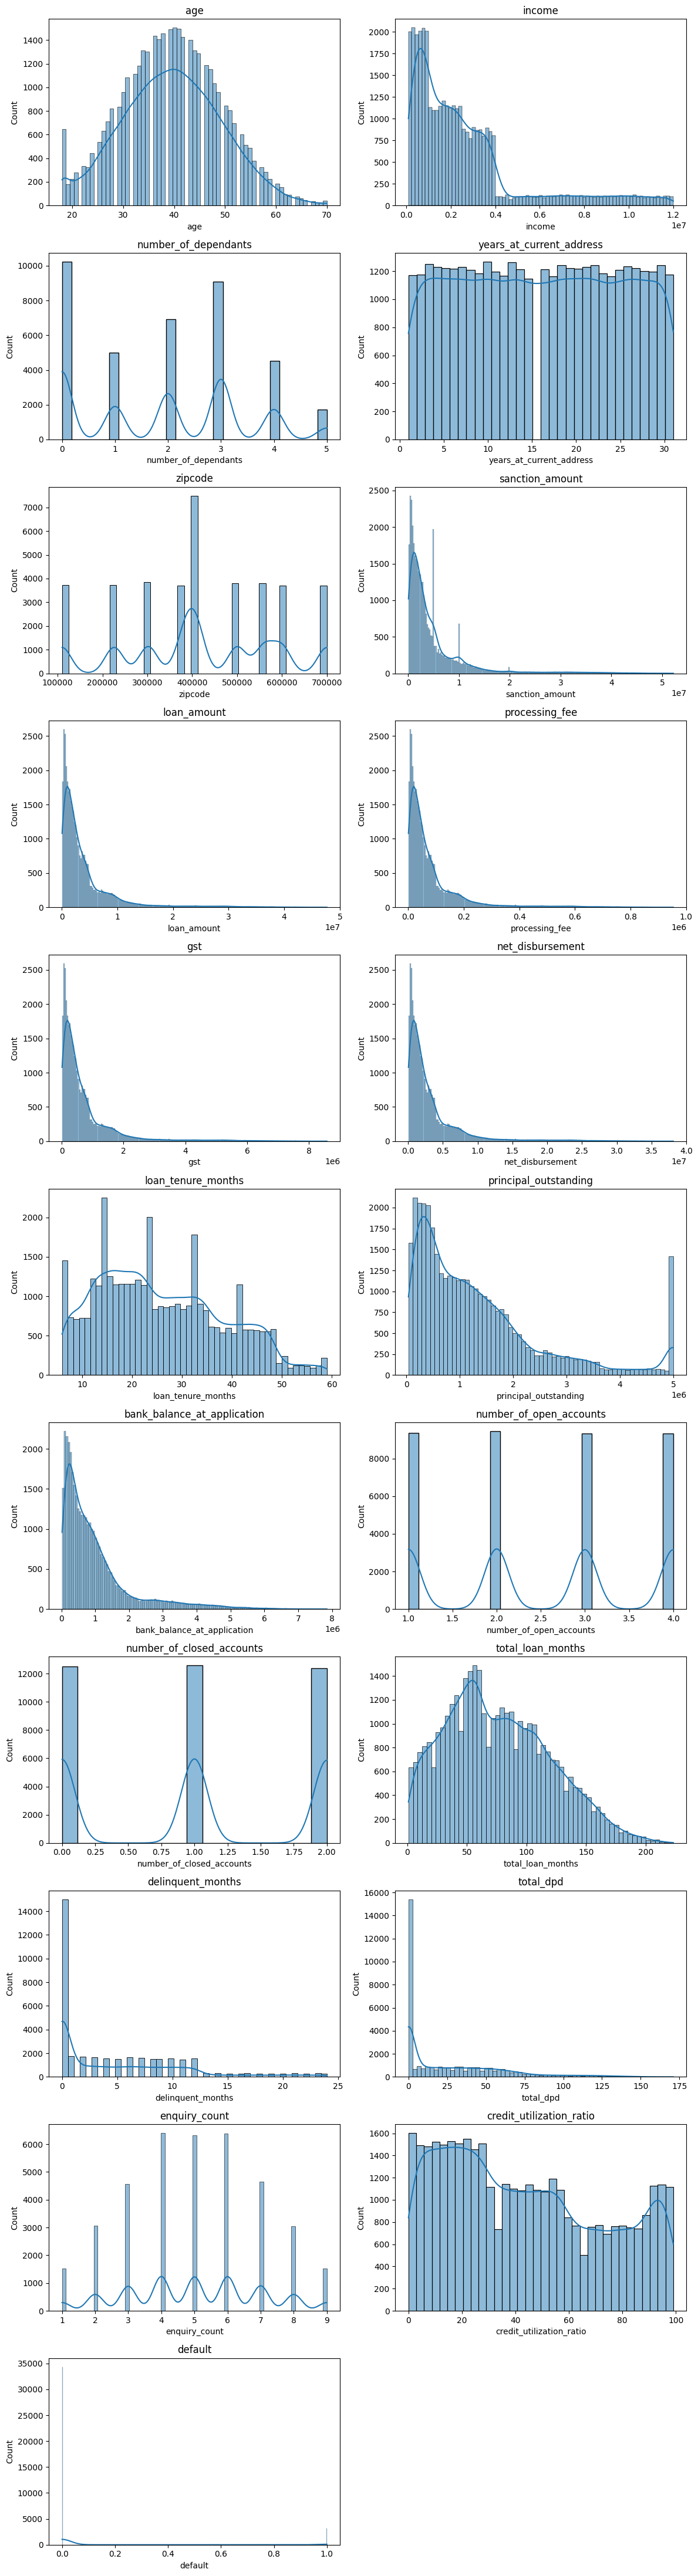

In [12]:
num_cols = Numerical_cols
n = len(num_cols)

plt.figure(figsize=(12, 4 * ((n + 1) // 2)))

for i, col in enumerate(num_cols):
    plt.subplot((n + 1) // 2, 2, i + 1)
    sns.histplot(df_train_preprocessed[col].dropna(), kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

 Skewness value for each numerical columns 
- Symmetric Distribution = 0
- right-skewed = > 0
- left-skewed = < 0
- Highly-skewed = > 1 or < -1

In [13]:
df_train_preprocessed.skew(numeric_only=True)

age                            0.082967
income                         1.775284
number_of_dependants           0.147562
years_at_current_address       0.002588
zipcode                       -0.139689
sanction_amount                3.223317
loan_amount                    3.291583
processing_fee                 3.291583
gst                            3.291583
net_disbursement               3.291583
loan_tenure_months             0.426683
principal_outstanding          1.478575
bank_balance_at_application    2.125029
number_of_open_accounts        0.006131
number_of_closed_accounts      0.005920
total_loan_months              0.421774
delinquent_months              1.237157
total_dpd                      1.298350
enquiry_count                 -0.003310
credit_utilization_ratio       0.340733
default                        2.974690
dtype: float64

Skewness analysis shows:

- Most demographic and count-based features (age, dependants, accounts, enquiries) are approximately symmetric.

- Financial variables (income, loan_amount, sanction_amount, bank_balance, fees, GST) are highly    right-skewed, indicating a few high-value customers and many lower-value borrowers — typical in lending datasets.

- Risk-related variables (DPD, delinquent_months, principal_outstanding) are moderately right-skewed, reflecting a small group of high-risk borrowers.

- The target variable (default) is highly skewed, suggesting possible class imbalance.

- Similar skewness values among loan_amount, processing_fee, GST, and net_disbursement indicate potential multicollinearity.

#### 2. KDE plot for all Numerical Features

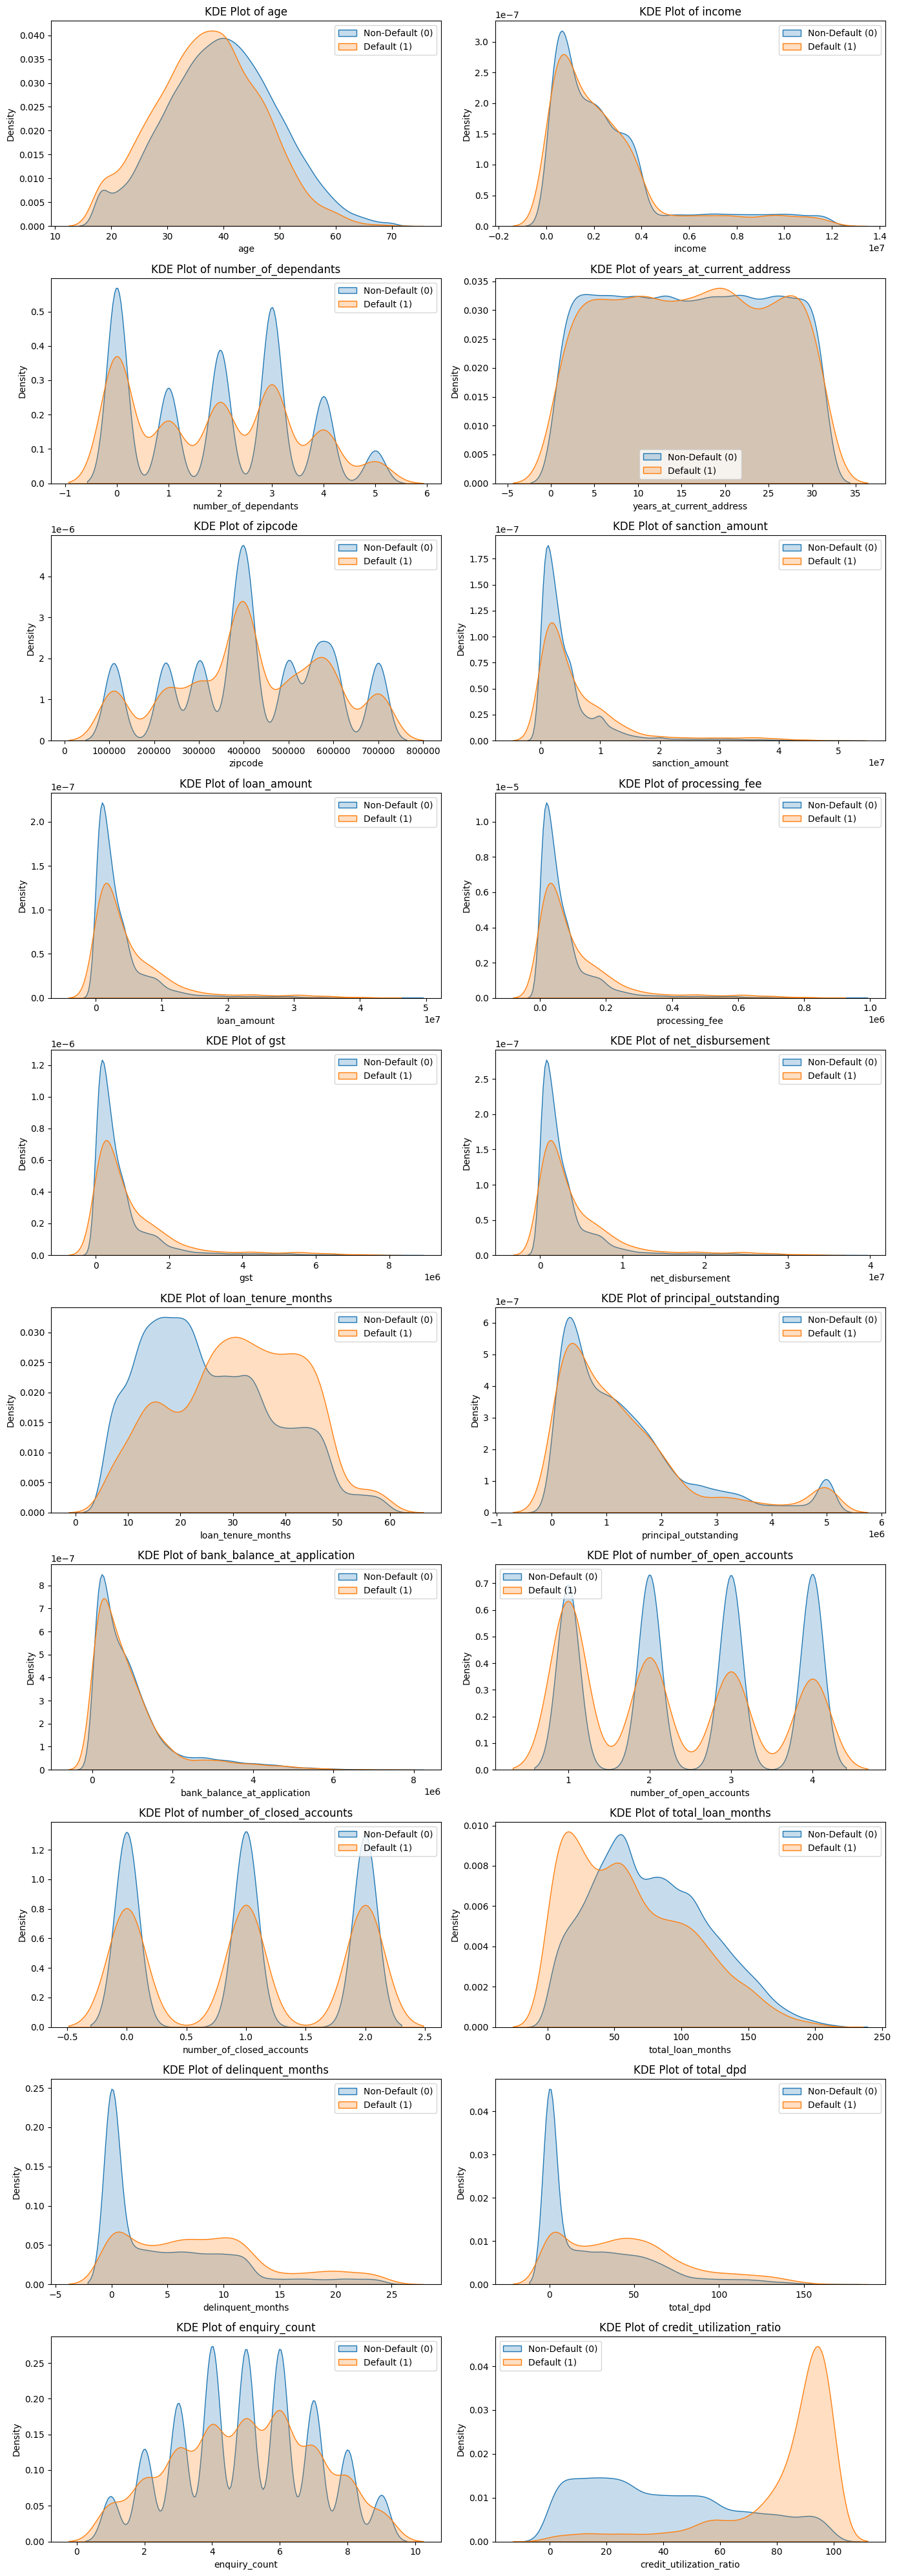

In [14]:
# Select numeric columns except target
num_cols = df_train_preprocessed.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('default')

# Set plot size
n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(14, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    
    sns.kdeplot(data=df_train_preprocessed[df_train_preprocessed['default'] == 0], x=col, fill=True, label='Non-Default (0)', common_norm=False)
    sns.kdeplot(data=df_train_preprocessed[df_train_preprocessed['default'] == 1], x=col, fill=True, label='Default (1)', common_norm=False)
    
    plt.title(f'KDE Plot of {col}')
    plt.legend()

plt.tight_layout()
plt.show()

1. Strong Predictors:
- total_dpd 
- delinquent_months 
- credit_utilization_ratio 
- loan_amount / sanction_amount
- income
- bank_balance

2. Weak Predictors:
- age
- dependants
- years_at_current_address
- number_of_closed_accounts
- enquiry_count

#### 3. Correlation Matrix

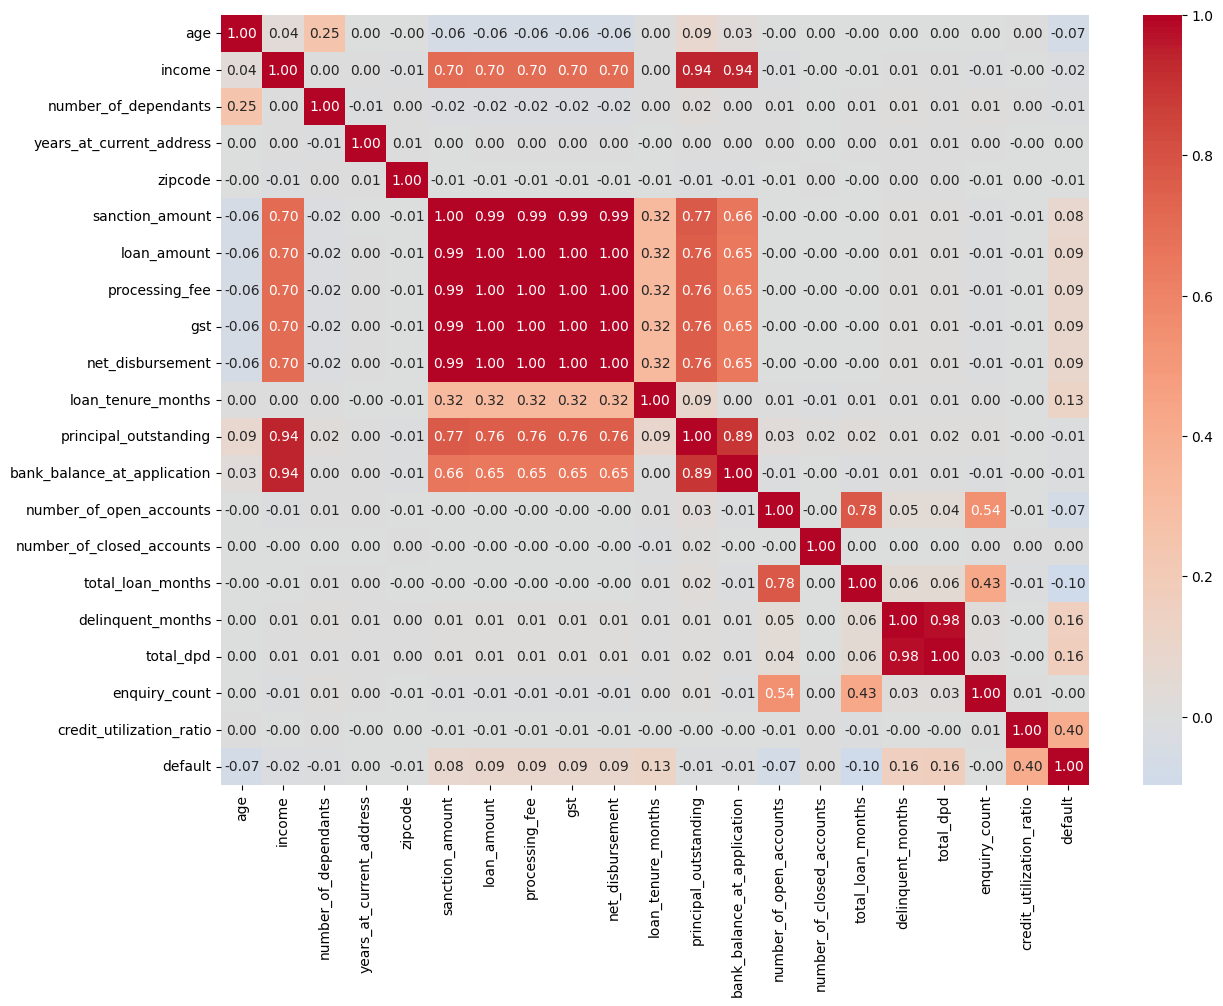

In [15]:
plt.figure(figsize=(14,10))
numeric_cols = df_train_preprocessed.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.show()

1. Extremely High Correlation (~0.99 – 1.00)

These variables are almost duplicates of each other:

- sanction_amount
- loan_amount
- processing_fee
- gst
- net_disbursement

All of them have correlation ≈ 0.99–1.00 with each other.

2. Very High Correlation (~0.94)

- income ↔ principal_outstanding (~0.94)
- income ↔ bank_balance_at_application (~0.94)

These financial capacity variables are strongly linked.

3. High Correlation (~0.89)

- principal_outstanding ↔ bank_balance_at_application (~0.89)

Again, indicating overlapping financial strength indicators.

4. Very High Delinquency Correlation (~0.98)

- delinquent_months ↔ total_dpd (~0.98)

These measure almost the same repayment behavior.

5. Moderately High (~0.78)

number_of_open_accounts ↔ total_loan_months (~0.78)